# Explorar las conexiones de datos con correlaciones 📊🔗 I

## Objetivos academicos

## Correlación 📊🔗

La **correlación** es una medida estadística que indica **qué tan relacionadas están dos variables** y en qué dirección lo hacen. En análisis de datos es muy útil porque nos ayuda a **detectar patrones**, generar **hipótesis** y priorizar variables antes de construir modelos o tomar decisiones de negocio.

> 👉 *La correlación no explica el porqué, pero sí nos dice “qué se mueve junto con qué”*.

---

### ¿Por qué es útil la correlación?
- Explora relaciones entre variables numéricas 📈
- Ayuda a reducir dimensionalidad (eliminar variables redundantes)
- Permite detectar señales tempranas en datos de negocio
- Es un paso clave antes de modelos predictivos

---

### ¿Cómo se mide la correlación?
La correlación se mide mediante **coeficientes** que toman valores entre **-1 y 1**:

- **1** → relación positiva perfecta  
- **-1** → relación negativa perfecta  
- **0** → no hay relación lineal

En Python, normalmente se calcula a partir de un *DataFrame* usando métodos como `.corr()`.

---

### Medidas de correlación más comunes 📐

- **Pearson**  
  - Mide relación *lineal*
  - Sensible a outliers  
  - Ideal para variables numéricas continuas  
  - Supone distribución aproximadamente normal

- **Spearman**  
  - Mide relación *monótona* (no necesariamente lineal)
  - Usa rangos en lugar de valores originales  
  - Más robusta ante outliers  
  - Útil cuando la relación no es lineal

- **Kendall**  
  - Similar a Spearman, pero más conservadora  
  - Funciona bien con muestras pequeñas

- **Biserial / Point-Biserial**  
  - Relaciona una variable numérica con una binaria  
  - Muy usada en análisis de comportamiento (ej. compra vs no compra)

---

### Correlación vs Causalidad ⚠️
Uno de los errores más comunes en análisis de datos es asumir que:

> *Si A se correlaciona con B, entonces A causa B*

Esto **no es cierto**.  
La correlación **no implica causalidad**. Puede haber:
- Variables ocultas
- Coincidencias estadísticas
- Relaciones indirectas

> 🧠 *La correlación genera hipótesis; la causalidad requiere experimentación.*

---

### Ética en el análisis de correlaciones ⚖️
El uso irresponsable de correlaciones puede llevar a:
- Conclusiones incorrectas
- Decisiones injustas
- Modelos sesgados

Por eso es importante:
- Validar contexto y dominio del problema
- Evitar interpretaciones simplistas
- Documentar supuestos y limitaciones

---

### ❌ No usar correlación para discriminar
Nunca se deben usar correlaciones para:
- Justificar discriminación por género, edad, origen o condición social
- Tomar decisiones automáticas sin supervisión humana
- Penalizar grupos por relaciones estadísticas débiles o espurias

> ✅ *Un buen analista no solo mide relaciones, también mide impacto.*

---

📌 **Conclusión**  
La correlación es una herramienta poderosa para explorar datos, pero debe usarse con **criterio estadístico, sentido crítico y responsabilidad ética**.


In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import  OrdinalEncoder, LabelEncoder

In [41]:

df=pd.read_csv('https://raw.githubusercontent.com/alicenkbaytop/German-Credit-Risk-Classification/refs/heads/master/german_credit_risk.csv')
df.dropna(inplace=True)
df.drop(columns=['Unnamed: 0'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522 entries, 1 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               522 non-null    int64 
 1   Sex               522 non-null    object
 2   Job               522 non-null    int64 
 3   Housing           522 non-null    object
 4   Saving accounts   522 non-null    object
 5   Checking account  522 non-null    object
 6   Credit amount     522 non-null    int64 
 7   Duration          522 non-null    int64 
 8   Purpose           522 non-null    object
 9   Risk              522 non-null    object
dtypes: int64(4), object(6)
memory usage: 44.9+ KB


df[']

In [42]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [43]:
orden_niveles = [["little", "moderate", "quite rich","rich"]]  # orden explícito
oe = OrdinalEncoder(categories=orden_niveles)
df["saving_accounts_ord"] = oe.fit_transform(df[["Saving accounts"]])


In [44]:
orden_niveles = [["little", "moderate", "rich"]]  # orden explícito
oet = OrdinalEncoder(categories=orden_niveles)
df["checking_accounts_ord"] = oet.fit_transform(df[["Checking account"]])

In [ ]:
orden_niveles = [["little", "moderate", "rich"]]  # orden explícito
oet = OrdinalEncoder(categories=orden_niveles)
df["checking_accounts_ord"] = oet.fit_transform(df[["Checking account"]])

In [45]:
le = LabelEncoder()
df["Risk"] = le.fit_transform(df["Risk"])

In [47]:
df.Housing.unique()

array(['own', 'free', 'rent'], dtype=object)

In [46]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,saving_accounts_ord,checking_accounts_ord
1,22,female,2,own,little,moderate,5951,48,radio/TV,0,0.0,1.0
3,45,male,2,free,little,little,7882,42,furniture/equipment,1,0.0,0.0
4,53,male,2,free,little,little,4870,24,car,0,0.0,0.0
7,35,male,3,rent,little,moderate,6948,36,car,1,0.0,1.0
9,28,male,3,own,little,moderate,5234,30,car,0,0.0,1.0


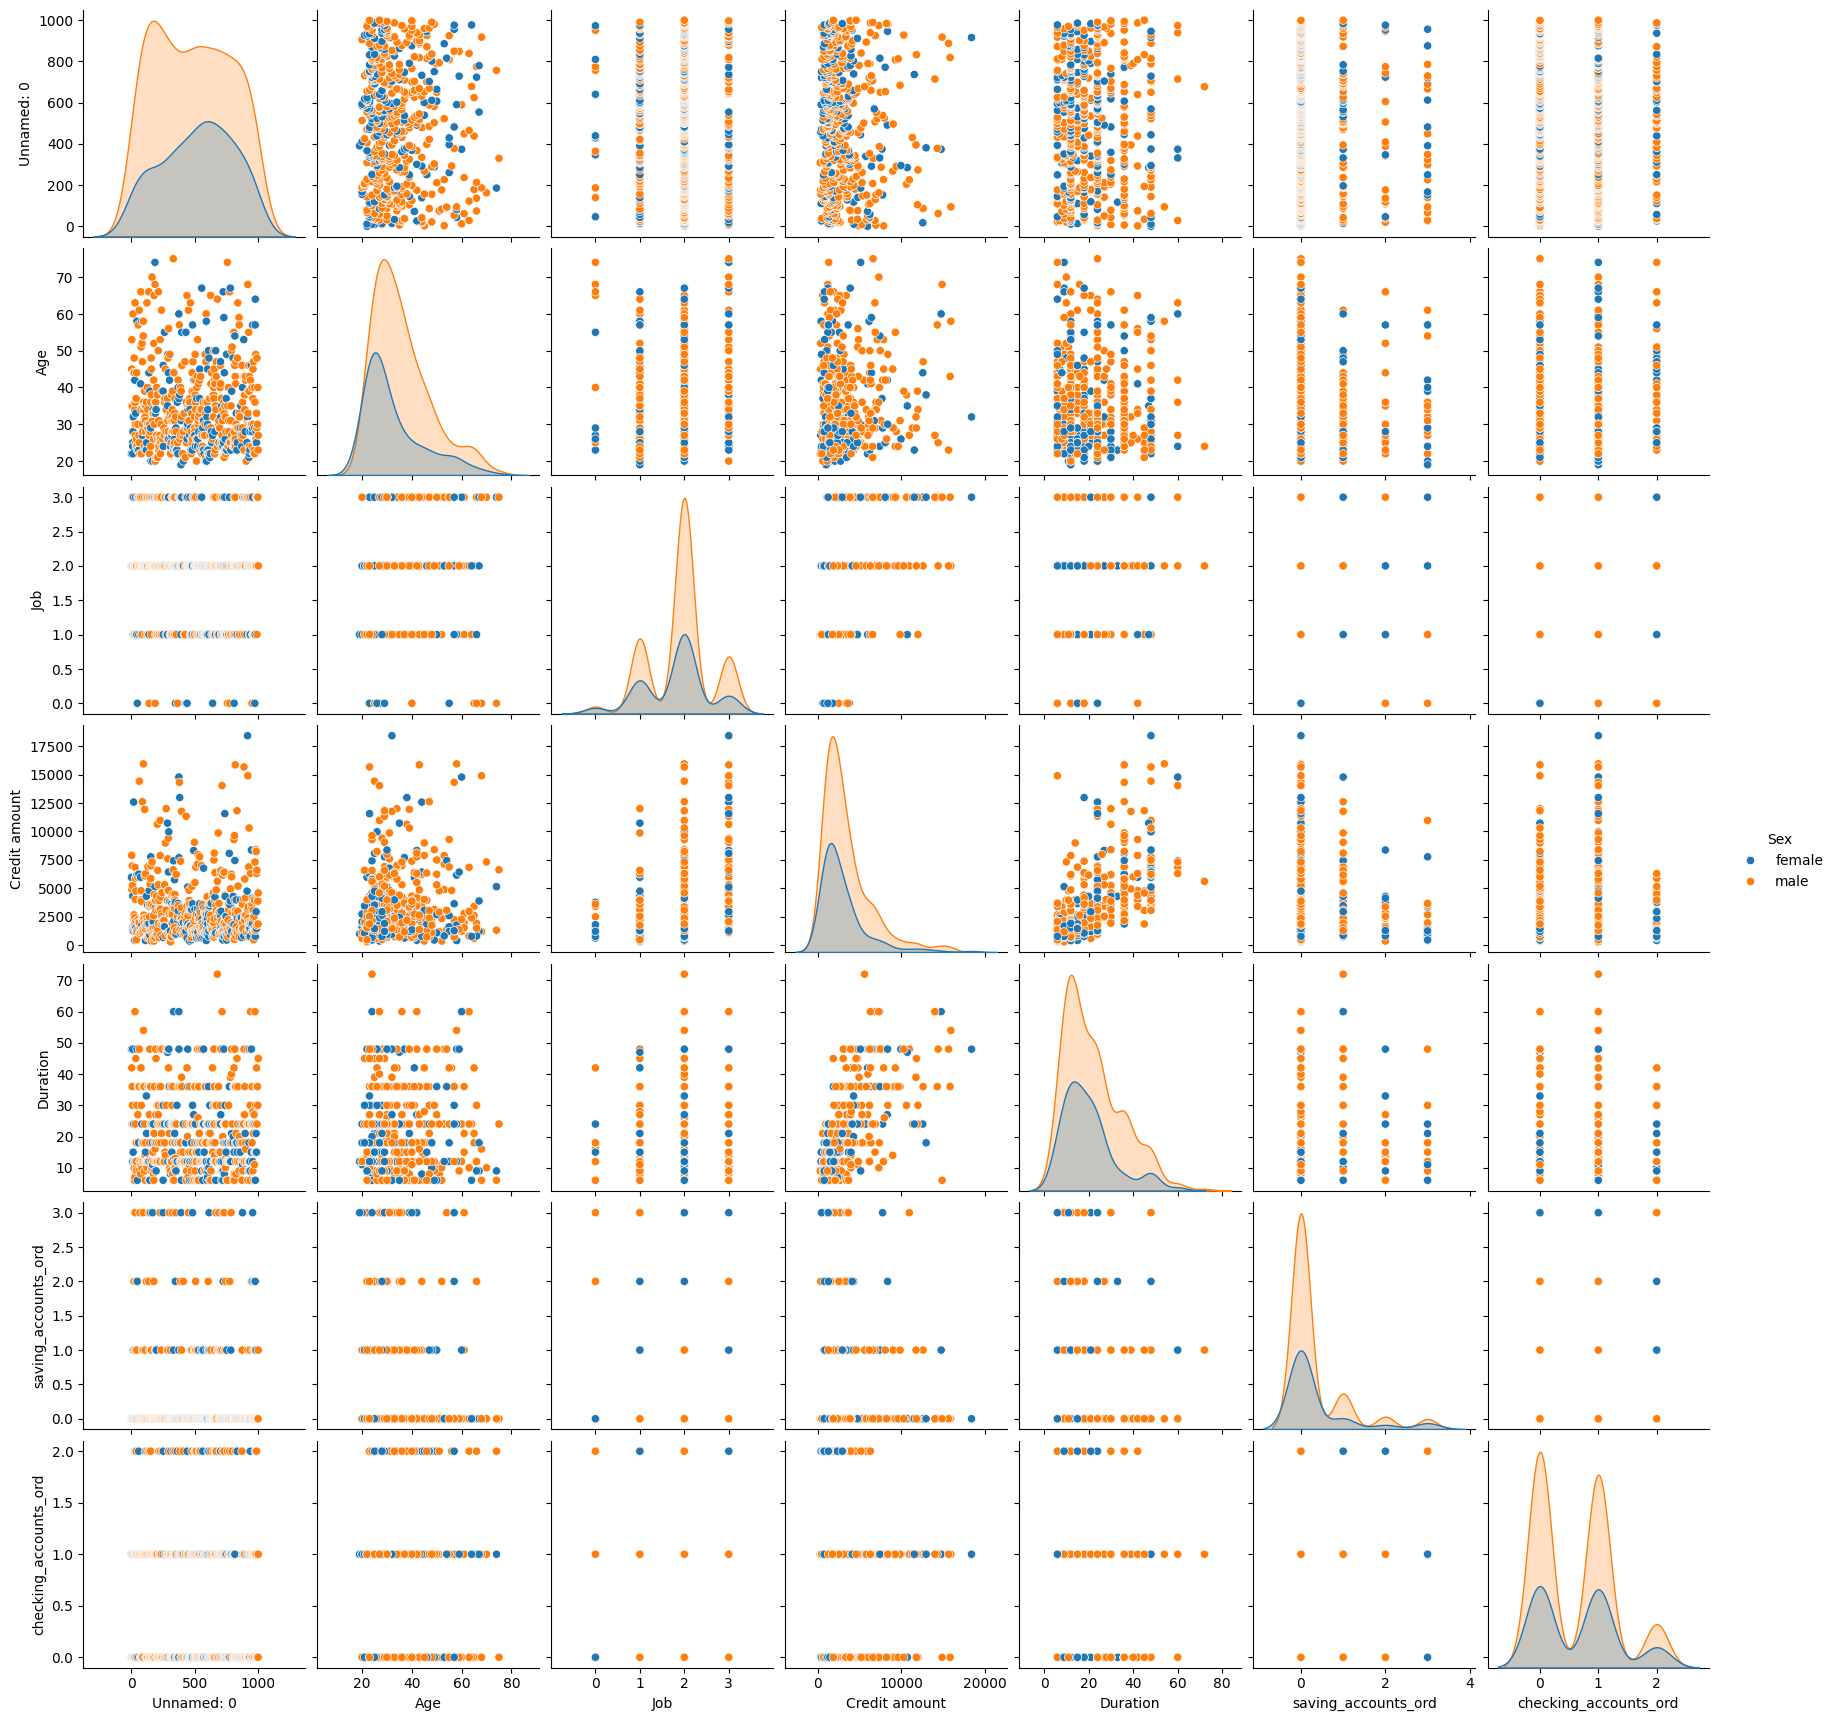

In [27]:
sns.pairplot(df, hue="Sex")

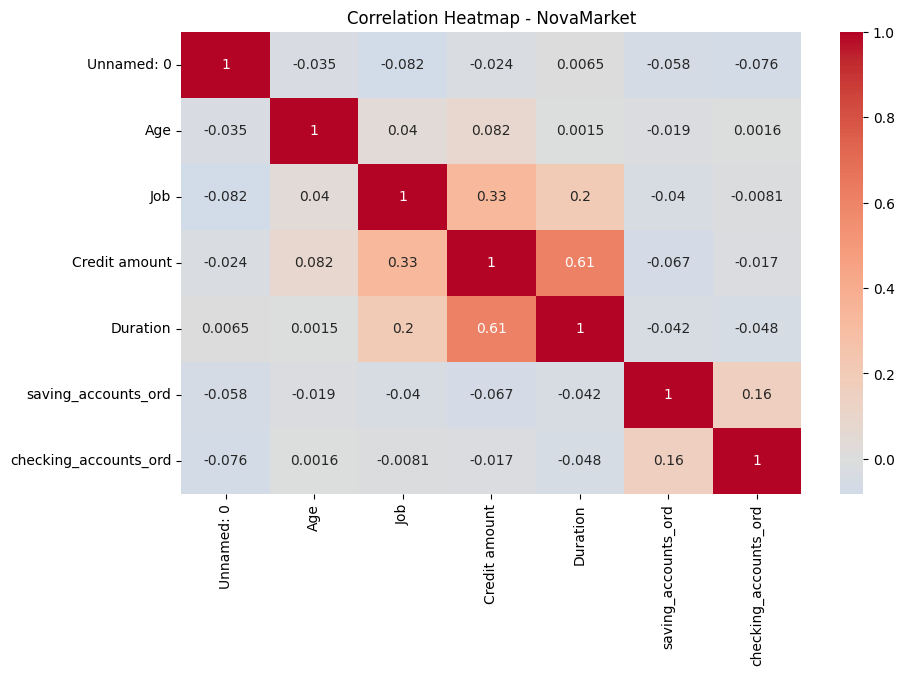

In [28]:

corr = df.select_dtypes(exclude=['object']).corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - NovaMarket")
plt.show()